# Axion PINN V12 — Restricted Sub-Domain + WKB ICs from ODE Boundary

## V11 Failure (Final Diagnosis)

Even with the 1st-order system, `d(φ̇)/dt = d(φ̇)/ds · ds/dt` where `ds/dt = 1/(t·log_dt)`.

| t | ds/dt | phi_cons (untrained) |
|---|---|---|
| 1e-10 | 4.34×10⁸ | 8.96×10⁶ |
| 1e-06 | 4.35×10⁴ | 6.77×10² |
| 1e-03 | 1.45×10² | **1.60** ✓ |

The problem is NOT the order of the equation — it is the **extreme log-compression** of
10 decades into τ ∈ [0,1]. Any network derivative at small τ gets amplified by `dτ/dt → ∞`.

## V12 Strategy: Restrict PINN to t ∈ [t_split, t_end]

**Physical motivation:** The interesting physics (oscillation onset, amplitude decay,
Hubble back-reaction) all occurs at t > 1/mₐ = 0.01. The early radiation era (t < 1e-3)
is analytically identical to simple power laws — no PINN needed there.

### Sub-domain normalization
```
s = (log t − log t_split) / (log t_end − log t_split)  ∈ [0, 1]
```
With `t_split ≈ 1e-3` (τ_split = 0.70):
- `ds/dt` at t=1e-3: **145** (vs 4.34×10⁸ for full domain)
- All physics losses remain O(1) throughout training

### WKB ICs at t_split (exact by construction)

Solve 2×2 rotation system at c = mₐ·t_split:
```
A₀ = φ_spl·cos(c) − (φ̇_spl/mₐ)·sin(c)
B₀ = φ_spl·sin(c) + (φ̇_spl/mₐ)·cos(c)
```
Consistency IC for dphi_net (WKB approximation):
```
C₀ = B₀·mₐ,   D₀ = −A₀·mₐ
```
→ R_φ|_{s=0} = dφ/dt − φ̇_net|_{s=0} = 0 **exactly**

### Architecture
- `ScaleFactorNet_V12(s)`: `a_split · exp(clamp(s·g(s), max=50))`
- `PhiNet_V12(s, t)`:  `(A₀ + s²·fₐ(s))·cos(mₐt) + (B₀ + s²·f_B(s))·sin(mₐt)`
- `DPhiNet_V12(s, t)`: `(C₀ + s²·f_C(s))·cos(mₐt) + (D₀ + s²·f_D(s))·sin(mₐt)`

### Evaluation
- t < t_split: ODE interpolation (sub-ppm accuracy, physics trivial there)  
- t ≥ t_split: PINN prediction


In [25]:
"""Imports and global config — float64 throughout."""
import os, time, warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)
print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

# ── Full-domain log-time helpers (for ODE reference only) ─────────────────────
_LOG_T0 = np.log(PARAMS['t_init'])
_LOG_T1 = np.log(PARAMS['t_end'])
_LOG_DT = _LOG_T1 - _LOG_T0        # ≈ 23.026

def t_to_tau(t_np):
    """numpy version for ODE processing."""
    return (np.log(np.maximum(t_np, 1e-300)) - _LOG_T0) / _LOG_DT

# ── Sub-domain log-time helpers (PINN domain: t_split ≤ t ≤ t_end) ──────────
TAU_SPLIT    = 0.70
_LOG_T_SPLIT = _LOG_T0 + TAU_SPLIT * _LOG_DT   # = log(t_split) ≈ log(1e-3)
_SUB_LOG_DT  = _LOG_DT * (1.0 - TAU_SPLIT)     # ≈ 6.908  (log(t_end/t_split))
T_SPLIT_NP   = float(np.exp(_LOG_T_SPLIT))      # ≈ 1e-3

def t_to_s(t_tensor):
    """Map t ∈ [t_split, t_end] → s ∈ [0, 1]."""
    return (torch.log(torch.clamp(t_tensor, min=EPS)) - _LOG_T_SPLIT) / _SUB_LOG_DT

def s_to_t(s_tensor):
    """Inverse: s ∈ [0, 1] → t ∈ [t_split, t_end]."""
    return torch.exp(_LOG_T_SPLIT + s_tensor * _SUB_LOG_DT)

print(f"PARAMS defined.")
print(f"t_split = {T_SPLIT_NP:.3e}  (tau_split={TAU_SPLIT})")
print(f"ds/dt at t_split = {1.0/(T_SPLIT_NP * _SUB_LOG_DT):.1f}  (was 4.34e8 in V11)")
print(f"ds/dt at t=1     = {1.0/(1.0   * _SUB_LOG_DT):.3f}")


PyTorch 2.12.0+cpu | device=cpu | dtype=torch.float64
PARAMS defined.
t_split = 1.000e-03  (tau_split=0.7)
ds/dt at t_split = 144.8  (was 4.34e8 in V11)
ds/dt at t=1     = 0.145


In [26]:
# ── ODE reference ──────────────────────────────────────────────────────────────
def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s  = max(a, 1e-30)
    rax  = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1   = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]

def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    print("Solving ODE reference (RK45)...")
    t0w = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t0w:.2f}s | success={sol.success}")
    if not sol.success:
        warnings.warn(sol.message)
    return sol   # sol.y[0]=a, sol.y[1]=phi, sol.y[2]=phi_dot


def physics_residuals_v12(a, phi, dphi, da_dt, d_dphi_dt,
                           ma, rho_m0, rho_r0, rho_L):
    """First-order residuals (same as V11) — NO d²φ/dt² required."""
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*dphi**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)
    # Friedmann
    E1  = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1  = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F = da_dt - H1
    # Klein-Gordon (1st order)
    E2   = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2   = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG = d_dphi_dt + sqrt3*H2*dphi + ma**2*phi
    return R_F, R_KG

print("ODE + physics residuals defined.")


ODE + physics residuals defined.


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# FCNN — tanh MLP, input s ∈ [0,1]
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, s):
        return self.net(s)


# ─────────────────────────────────────────────────────────────────────────────
# ScaleFactorNet_V12
#   a(t) = a_split · exp(clamp(s · g(s), max=50))
#   Hard IC: a(t_split) = a_split  [s(t_split) = 0]
#   g_init calibrated from ODE sub-domain (set via set_g_init)
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet_V12(nn.Module):
    def __init__(self, a_split, hidden=64, depth=5):
        super().__init__()
        self.register_buffer('log_a_split', torch.tensor(np.log(float(a_split)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def set_g_init(self, g_star):
        for m in reversed(list(self.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, float(g_star))
                break

    def forward(self, s):
        return torch.exp(self.log_a_split + torch.clamp(s * self.net(s), max=50.0))


# ─────────────────────────────────────────────────────────────────────────────
# PhiNet_V12 — WKB with exact hard IC at t_split
#
#   φ(t) = A(s)·cos(mₐt) + B(s)·sin(mₐt)
#   A(s) = A0 + s²·net_A(s)    → A(0) = A0, dA/ds|₀ = 0
#   B(s) = B0 + s²·net_B(s)    → B(0) = B0, dB/ds|₀ = 0
#
#   A0, B0 from WKB rotation at c = mₐ·t_split:
#     A0 = φ_spl·cos(c) − (φ̇_spl/mₐ)·sin(c)
#     B0 = φ_spl·sin(c) + (φ̇_spl/mₐ)·cos(c)
#   → φ(t_split) = φ_spl  EXACTLY  ✓
# ─────────────────────────────────────────────────────────────────────────────
class PhiNet_V12(nn.Module):
    def __init__(self, A0, B0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('A0', torch.tensor(float(A0), dtype=DTYPE))
        self.register_buffer('B0', torch.tensor(float(B0), dtype=DTYPE))
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_A = FCNN(1, 1, hidden, depth)
        self.net_B = FCNN(1, 1, hidden, depth)

    def forward(self, s, t):
        A = self.A0 + s**2 * self.net_A(s)
        B = self.B0 + s**2 * self.net_B(s)
        return A * torch.cos(self.ma * t) + B * torch.sin(self.ma * t)


# ─────────────────────────────────────────────────────────────────────────────
# DPhiNet_V12 — WKB for φ̇ with IC consistent with PhiNet
#
#   φ̇(t) = C(s)·cos(mₐt) + D(s)·sin(mₐt)
#   C(s) = C0 + s²·net_C(s)    → C(0) = C0 = B0·mₐ
#   D(s) = D0 + s²·net_D(s)    → D(0) = D0 = −A0·mₐ
#
#   In WKB approx: φ̇ ≈ B·mₐ·cos − A·mₐ·sin → φ̇(t_split) = φ̇_spl  ✓
#   R_φ = dφ/dt − φ̇_net|_{s=0} = 0  EXACTLY  ✓
# ─────────────────────────────────────────────────────────────────────────────
class DPhiNet_V12(nn.Module):
    def __init__(self, C0, D0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('C0', torch.tensor(float(C0), dtype=DTYPE))
        self.register_buffer('D0', torch.tensor(float(D0), dtype=DTYPE))
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_C = FCNN(1, 1, hidden, depth)
        self.net_D = FCNN(1, 1, hidden, depth)

    def forward(self, s, t):
        C = self.C0 + s**2 * self.net_C(s)
        D = self.D0 + s**2 * self.net_D(s)
        return C * torch.cos(self.ma * t) + D * torch.sin(self.ma * t)


# ─────────────────────────────────────────────────────────────────────────────
# AxionPINN_V12 — restricted sub-domain PINN (t ∈ [t_split, t_end])
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN_V12(nn.Module):
    def __init__(self, a_split, A0, B0, C0, D0, ma,
                 a_hidden=64,    a_depth=5,
                 phi_hidden=64,  phi_depth=4,
                 dphi_hidden=64, dphi_depth=4):
        super().__init__()
        self.register_buffer('_log_t_split', torch.tensor(_LOG_T_SPLIT, dtype=DTYPE))
        self.register_buffer('_sub_log_dt',  torch.tensor(_SUB_LOG_DT,  dtype=DTYPE))
        self.a_net    = ScaleFactorNet_V12(a_split, a_hidden, a_depth)
        self.phi_net  = PhiNet_V12(A0, B0, ma, phi_hidden, phi_depth)
        self.dphi_net = DPhiNet_V12(C0, D0, ma, dphi_hidden, dphi_depth)

    def _to_s(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t_split) / self._sub_log_dt

    def forward(self, t):
        """Returns a, phi, dphi — all (N,1). t must be >= t_split."""
        s    = self._to_s(t)
        a    = self.a_net(s)
        phi  = self.phi_net(s, t)
        dphi = self.dphi_net(s, t)
        return a, phi, dphi


# ── Compute WKB ICs (needs ODE solution) — placeholder check with zero ICs ───
print("Classes defined: FCNN, ScaleFactorNet_V12, PhiNet_V12, DPhiNet_V12, AxionPINN_V12")
print("(ICs will be computed from ODE in the solver __init__)")


Classes defined: FCNN, ScaleFactorNet_V12, PhiNet_V12, DPhiNet_V12, AxionPINN_V12
(ICs will be computed from ODE in the solver __init__)


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# AxionPINNSolver_V12  —  Restricted sub-domain solver with ODE ICs
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINNSolver_V12:
    """
    Restricted-domain PINN: t ∈ [t_split, t_end], s = log(t/t_split)/sub_log_dt ∈ [0,1].
    • ICs at t_split from ODE.
    • WKB rotation sets A0/B0/C0/D0  →  R_φ|_{s=0} = 0 exactly.
    • No curriculum needed — uniform s ∈ [0,1] throughout.
    • For t < t_split: evaluation uses ODE interpolation (sub-ppm accuracy there).
    """

    # ── construction ─────────────────────────────────────────────────────────
    def __init__(self,
                 n_colloc   = 2000,
                 hidden     = 64,
                 depth_a    = 5,
                 depth_phi  = 4,
                 seed       = 42):
        torch.manual_seed(seed)
        np.random.seed(seed)

        # ── 1. ODE reference solution ─────────────────────────────────────
        sol = solve_ode(PARAMS)
        self.t_ode    = sol.t                          # shape (N_ode,)
        self.a_ode    = sol.y[0]                       # a(t) directly
        self.phi_ode  = sol.y[1]
        self.dphi_ode = sol.y[2]

        T_SPLIT = float(np.exp(_LOG_T_SPLIT))

        # ── 2. Interpolate ICs at t_split ─────────────────────────────────
        a_spl    = float(np.interp(T_SPLIT, self.t_ode, self.a_ode))
        phi_spl  = float(np.interp(T_SPLIT, self.t_ode, self.phi_ode))
        dphi_spl = float(np.interp(T_SPLIT, self.t_ode, self.dphi_ode))

        # ── 3. WKB rotation to get A0, B0 at t_split ─────────────────────
        c   = PARAMS['ma'] * T_SPLIT          # ma*t_split ≈ 0.1
        ma  = PARAMS['ma']
        A0  = phi_spl * np.cos(c) - (dphi_spl / ma) * np.sin(c)
        B0  = phi_spl * np.sin(c) + (dphi_spl / ma) * np.cos(c)
        C0  = B0 * ma
        D0  = -A0 * ma
        print(f"t_split = {T_SPLIT:.4e}   a_spl = {a_spl:.4e}")
        print(f"phi_spl = {phi_spl:.6f}   dphi_spl = {dphi_spl:.4e}")
        print(f"c = ma*t_spl = {c:.4f} rad")
        print(f"A0 = {A0:.6f}   B0 = {B0:.6f}")
        print(f"C0 = {C0:.4e}   D0 = {D0:.4e}")

        # Verify IC recovery: A0*cos(c)+B0*sin(c) should == phi_spl
        phi_check = A0*np.cos(c) + B0*np.sin(c)
        print(f"IC check  φ: {phi_check:.8f}  (should be {phi_spl:.8f})")
        dphi_check = C0*np.cos(c) + D0*np.sin(c)
        print(f"IC check φ̇: {dphi_check:.6e}  (should be {dphi_spl:.6e})")

        # ── 4. ODE-calibrated g_star for a_net (sub-domain only) ──────────
        mask_sub = self.t_ode >= T_SPLIT * 0.9999
        s_sub    = (np.log(self.t_ode[mask_sub]) - _LOG_T_SPLIT) / _SUB_LOG_DT
        log_a_rel= np.log(self.a_ode[mask_sub] / a_spl)
        g_star   = float(np.dot(s_sub, log_a_rel) / np.dot(s_sub, s_sub))
        print(f"g_star (sub-domain) = {g_star:.4f}")

        # ── 5. Characteristic scales for loss normalisation ───────────────
        self.phi_scale  = float(np.max(np.abs(self.phi_ode)))   # ≈ 1.0
        dphi_late = self.dphi_ode[mask_sub]
        self.dphi_scale = float(np.std(dphi_late) + 1e-12)      # ≈ 66
        H_vals  = np.gradient(np.log(self.a_ode), self.t_ode)
        self.H_ref = float(np.median(np.abs(H_vals[mask_sub])))  # rough H scale
        print(f"phi_scale={self.phi_scale:.2f}  dphi_scale={self.dphi_scale:.3e}  H_ref={self.H_ref:.3e}")

        # ── 6. ODE reference tensors for anchor / pretrain ────────────────
        t_sub = self.t_ode[mask_sub]
        self.t_sub    = t_sub
        self.a_sub    = self.a_ode[mask_sub]
        self.phi_sub  = self.phi_ode[mask_sub]
        self.dphi_sub = self.dphi_ode[mask_sub]

        t_ref_t          = torch.tensor(t_sub[:, None], dtype=DTYPE)
        self.t_ref_torch = t_ref_t
        self.la_ref      = torch.tensor(np.log(self.a_sub[:, None]), dtype=DTYPE)
        self.phi_ref_torch  = torch.tensor(self.phi_sub[:, None],  dtype=DTYPE)
        self.dphi_ref_torch = torch.tensor(self.dphi_sub[:, None], dtype=DTYPE)

        # ── 7. Build model ────────────────────────────────────────────────
        self.model = AxionPINN_V12(
            a_split=a_spl,
            A0=A0, B0=B0, C0=C0, D0=D0,
            ma=ma,
            a_hidden=hidden,   a_depth=depth_a,
            phi_hidden=hidden, phi_depth=depth_phi,
            dphi_hidden=hidden, dphi_depth=depth_phi,
        )
        self.model.a_net.set_g_init(g_star)

        self.n_colloc = n_colloc
        self.T_SPLIT  = T_SPLIT
        self.loss_log = []

    # ── collocation points uniform in s ∈ [0,1] ──────────────────────────
    def _make_colloc(self, n=None):
        if n is None: n = self.n_colloc
        s_b = torch.rand(n, 1, dtype=DTYPE)
        return s_to_t(s_b).requires_grad_(True)

    # ── physics loss (first-order, same normalisation as V11) ─────────────
    def _physics_loss(self, t_col):
        p = PARAMS
        a, phi, dphi = self.model(t_col)
        ones = torch.ones_like(a)
        da_dt     = torch.autograd.grad(
            a,    t_col, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d_dphi_dt = torch.autograd.grad(
            dphi, t_col, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d_phi_dt  = torch.autograd.grad(
            phi,  t_col, grad_outputs=ones, create_graph=True)[0]
        R_F, R_KG = physics_residuals_v12(
            a, phi, dphi, da_dt, d_dphi_dt,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'])
        R_phi = d_phi_dt - dphi   # φ-consistency
        # Dynamic H normalisation (avoids fixed H_ref being off-scale)
        with torch.no_grad():
            a_d = a.detach().clamp(min=EPS)
            rax_d = 0.5*dphi.detach()**2 + 0.5*p['ma']**2*phi.detach()**2
            E1_d  = rax_d + p['rho_m0']/a_d + p['rho_r0']/a_d**2 + p['rho_L']*a_d**2
            H_ref = torch.sqrt(torch.clamp(E1_d/3.0, min=1e-60))
        l_F   = torch.mean((R_F   / (H_ref + EPS))**2)
        l_KG  = torch.mean((R_KG  / (p['ma']**2 * self.phi_scale))**2)
        l_phi = torch.mean((R_phi / (self.dphi_scale + EPS))**2)
        return l_F, l_KG, l_phi

    # ── anchor loss (sub-domain ODE only) ────────────────────────────────
    def _anchor_loss(self):
        a_pred, phi_pred, dphi_pred = self.model(self.t_ref_torch)
        la_pred = torch.log(torch.clamp(a_pred, min=EPS))
        l_a   = torch.mean((la_pred   - self.la_ref)**2)
        l_phi = torch.mean((phi_pred  - self.phi_ref_torch)**2) / self.phi_scale**2
        l_dphi= torch.mean((dphi_pred - self.dphi_ref_torch)**2) / self.dphi_scale**2
        return l_a + l_phi + l_dphi

    # ── pretrain each subnet independently ───────────────────────────────
    def pretrain_a(self, epochs=8000, lr=1e-3):
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr)
        print(f"  Pretrain a_net  ({epochs} epochs)…", end='', flush=True)
        for ep in range(epochs):
            opt.zero_grad()
            a_p = self.model.a_net(self.model._to_s(self.t_ref_torch))
            loss= torch.mean((torch.log(torch.clamp(a_p, min=EPS)) - self.la_ref)**2)
            loss.backward(); opt.step()
        print(f"  loss={loss.item():.3e}")

    def pretrain_phi(self, epochs=5000, lr=1e-3):
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr)
        print(f"  Pretrain phi_net ({epochs} epochs)…", end='', flush=True)
        for ep in range(epochs):
            opt.zero_grad()
            s_v = self.model._to_s(self.t_ref_torch)
            phi_p = self.model.phi_net(s_v, self.t_ref_torch)
            loss  = torch.mean((phi_p - self.phi_ref_torch)**2) / self.phi_scale**2
            loss.backward(); opt.step()
        print(f"  loss={loss.item():.3e}")

    def pretrain_dphi(self, epochs=5000, lr=1e-3):
        opt = torch.optim.Adam(self.model.dphi_net.parameters(), lr=lr)
        print(f"  Pretrain dphi_net ({epochs} epochs)…", end='', flush=True)
        for ep in range(epochs):
            opt.zero_grad()
            s_v   = self.model._to_s(self.t_ref_torch)
            dphi_p= self.model.dphi_net(s_v, self.t_ref_torch)
            loss  = torch.mean((dphi_p - self.dphi_ref_torch)**2) / self.dphi_scale**2
            loss.backward(); opt.step()
        print(f"  loss={loss.item():.3e}")

    # ── training stage: Adam with fixed hypers ────────────────────────────
    def _train_stage(self, epochs, lr, lam_fg, lam_kg, lam_phi, lam_anc, label='Stage'):
        opt  = torch.optim.Adam(self.model.parameters(), lr=lr)
        sched= torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        log_every = max(1, epochs // 20)
        print(f"\n  {label}  ({epochs} ep, lr={lr:.1e}, λ_anc={lam_anc:.2f})")
        t0 = time.time()
        for ep in range(1, epochs + 1):
            opt.zero_grad()
            t_col = self._make_colloc()
            l_F, l_KG, l_phi = self._physics_loss(t_col)
            l_anc = self._anchor_loss()
            loss  = lam_fg*l_F + lam_kg*l_KG + lam_phi*l_phi + lam_anc*l_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            opt.step(); sched.step()
            self.loss_log.append({
                'ep': ep, 'label': label,
                'F': l_F.item(), 'KG': l_KG.item(),
                'phi_cons': l_phi.item(), 'anc': l_anc.item(),
                'total': loss.item()
            })
            if ep % log_every == 0:
                print(f"    ep {ep:5d}/{epochs}  F={l_F.item():.2e}  "
                      f"KG={l_KG.item():.2e}  φ_cons={l_phi.item():.2e}  "
                      f"anc={l_anc.item():.2e}  t={time.time()-t0:.0f}s")

    # ── L-BFGS polish ─────────────────────────────────────────────────────
    def lbfgs_polish(self, max_iter=500, lam_fg=1.0, lam_kg=10.0, lam_phi=1.0, lam_anc=0.1):
        print(f"\n  L-BFGS polish ({max_iter} iter)…")
        opt = torch.optim.LBFGS(self.model.parameters(), max_iter=max_iter,
                                 tolerance_grad=1e-9, history_size=50,
                                 line_search_fn='strong_wolfe')
        t_col = self._make_colloc(n=4000)

        def closure():
            opt.zero_grad()
            l_F, l_KG, l_phi = self._physics_loss(t_col)
            l_anc = self._anchor_loss()
            loss  = lam_fg*l_F + lam_kg*l_KG + lam_phi*l_phi + lam_anc*l_anc
            loss.backward()
            return loss
        opt.step(closure)
        with torch.no_grad():
            t_col2 = self._make_colloc(n=4000)
            lF2, lKG2, lP2 = self._physics_loss(t_col2)
            lA2 = self._anchor_loss()
        print(f"  Post-L-BFGS  F={lF2.item():.2e}  KG={lKG2.item():.2e}  "
              f"φ_cons={lP2.item():.2e}  anc={lA2.item():.2e}")

    # ── full training pipeline ────────────────────────────────────────────
    def train_all(self):
        import time as _time
        global time
        time = _time
        t_wall = _time.time()

        print("=" * 60)
        print("V12 Training  —  Restricted sub-domain [t_split, t_end]")
        print("=" * 60)

        # — Pre-training —
        print("\n[1/4] Pre-training")
        self.pretrain_a(epochs=8000,  lr=1e-3)
        self.pretrain_phi(epochs=5000, lr=1e-3)
        self.pretrain_dphi(epochs=5000, lr=1e-3)

        # — Stage A: strong anchor, high lr —
        self._train_stage(
            epochs=8000, lr=5e-4,
            lam_fg=1.0, lam_kg=10.0, lam_phi=1.0, lam_anc=0.5,
            label='Stage A'
        )

        # — Stage B: lighter anchor, lower lr —
        self._train_stage(
            epochs=12000, lr=2e-4,
            lam_fg=1.0, lam_kg=10.0, lam_phi=1.0, lam_anc=0.2,
            label='Stage B'
        )

        # — L-BFGS polish —
        self.lbfgs_polish(max_iter=500)

        print(f"\nTotal wall time: {(_time.time()-t_wall)/60:.1f} min")

    # ── hybrid evaluation ─────────────────────────────────────────────────
    def evaluate(self, t_eval=None):
        """Hybrid: ODE for t < t_split, PINN for t ≥ t_split."""
        if t_eval is None:
            t_eval = np.logspace(
                np.log10(PARAMS['t_init']), np.log10(PARAMS['t_end']), 1000
            )
        a_pred    = np.empty_like(t_eval)
        phi_pred  = np.empty_like(t_eval)
        dphi_pred = np.empty_like(t_eval)

        mask_ode  = t_eval <  self.T_SPLIT
        mask_pinn = t_eval >= self.T_SPLIT

        # ODE region: sub-ppm interpolation
        if mask_ode.any():
            a_pred[mask_ode]    = np.interp(t_eval[mask_ode], self.t_ode, self.a_ode)
            phi_pred[mask_ode]  = np.interp(t_eval[mask_ode], self.t_ode, self.phi_ode)
            dphi_pred[mask_ode] = np.interp(t_eval[mask_ode], self.t_ode, self.dphi_ode)


        # PINN region

        if mask_pinn.any():
            t_ptorch = torch.tensor(t_eval[mask_pinn, None], dtype=DTYPE)
            with torch.no_grad():
                ap, pp, dp = self.model(t_ptorch)
            a_pred[mask_pinn]    = ap.numpy().ravel()
            phi_pred[mask_pinn]  = pp.numpy().ravel()
            dphi_pred[mask_pinn] = dp.numpy().ravel()
        return t_eval, a_pred, phi_pred, dphi_pred


print("AxionPINNSolver_V12 defined")

AxionPINNSolver_V12 defined


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Plotting utilities
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_loss_history(solver, save_path=None):
    if not solver.loss_log:
        print("No loss history."); return
    df = {k: [d[k] for d in solver.loss_log] for k in ['ep','F','KG','phi_cons','anc','total']}
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.semilogy(df['ep'], df['F'],        label='Friedmann', lw=1.2)
    ax.semilogy(df['ep'], df['KG'],       label='Klein-Gordon', lw=1.2)
    ax.semilogy(df['ep'], df['phi_cons'], label='φ consistency', lw=1.2)
    ax.semilogy(df['ep'], df['anc'],      label='Anchor', lw=1.2, ls='--')
    for ll in solver.loss_log:
        if ll['ep'] == 1 and ll.get('label', '') != solver.loss_log[0]['label']:
            ax.axvline(ll['ep'], color='grey', lw=0.5, ls=':')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Loss components')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogy(df['ep'], df['total'], color='navy', lw=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Total loss'); ax.set_title('Total loss')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


def plot_comparison(solver, save_path=None):
    t_eval, a_pred, phi_pred, dphi_pred = solver.evaluate()

    t_ode    = solver.t_ode
    a_ode    = solver.a_ode
    phi_ode  = solver.phi_ode
    dphi_ode = solver.dphi_ode

    T_SPLIT = solver.T_SPLIT

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    # ── Scale factor ─────────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.loglog(t_ode, a_ode, 'k-', lw=1.5, label='ODE')
    ax.loglog(t_eval[t_eval >= T_SPLIT], a_pred[t_eval >= T_SPLIT],
              'r--', lw=1.5, label='PINN (V12)')
    ax.axvline(T_SPLIT, color='blue', lw=0.8, ls=':', label=f't_split={T_SPLIT:.1e}')
    ax.set_xlabel('t'); ax.set_ylabel('a(t)'); ax.set_title('Scale factor')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    # ── a relative error ─────────────────────────────────────────────────
    ax = axes[0, 1]
    a_ref_interp = np.interp(t_eval, t_ode, a_ode)
    rel_a = np.abs(a_pred - a_ref_interp) / (np.abs(a_ref_interp) + 1e-15)
    mask_pinn = t_eval >= T_SPLIT
    ax.loglog(t_eval[mask_pinn], rel_a[mask_pinn], 'r-', lw=1.2)
    ax.axhline(1e-2, color='orange', ls='--', lw=0.8, label='1% line')
    ax.axhline(1e-4, color='green',  ls='--', lw=0.8, label='0.01% line')
    ax.set_xlabel('t'); ax.set_ylabel('|Δa|/a'); ax.set_title('Scale factor relative error')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    # ── φ(t) ─────────────────────────────────────────────────────────────
    ax = axes[1, 0]
    ax.semilogx(t_ode, phi_ode, 'k-', lw=1.5, label='ODE')
    ax.semilogx(t_eval[mask_pinn], phi_pred[mask_pinn], 'r--', lw=1.5, label='PINN')
    ax.axvline(T_SPLIT, color='blue', lw=0.8, ls=':')
    ax.set_xlabel('t'); ax.set_ylabel('φ(t)'); ax.set_title('Axion field φ')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    # ── φ relative error ─────────────────────────────────────────────────
    ax = axes[1, 1]
    phi_ref_interp = np.interp(t_eval, t_ode, phi_ode)
    rel_phi = np.abs(phi_pred - phi_ref_interp) / (np.abs(phi_ref_interp) + 1e-10)
    ax.loglog(t_eval[mask_pinn], rel_phi[mask_pinn], 'r-', lw=1.2)
    ax.axhline(1e-2, color='orange', ls='--', lw=0.8, label='1% line')
    ax.axhline(1e-4, color='green',  ls='--', lw=0.8, label='0.01% line')
    ax.set_xlabel('t'); ax.set_ylabel('|Δφ|/|φ|'); ax.set_title('φ relative error')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    # ── φ̇(t) ─────────────────────────────────────────────────────────────
    ax = axes[2, 0]
    ax.semilogx(t_ode, dphi_ode, 'k-', lw=1.5, label='ODE')
    ax.semilogx(t_eval[mask_pinn], dphi_pred[mask_pinn], 'r--', lw=1.5, label='PINN')
    ax.axvline(T_SPLIT, color='blue', lw=0.8, ls=':')
    ax.set_xlabel('t'); ax.set_ylabel('φ̇(t)'); ax.set_title('φ̇ (axion velocity)')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    # ── φ̇ relative error ─────────────────────────────────────────────────
    ax = axes[2, 1]
    dphi_ref_interp = np.interp(t_eval, t_ode, dphi_ode)
    rel_dphi = np.abs(dphi_pred - dphi_ref_interp) / (np.abs(dphi_ref_interp) + 1e-6)
    ax.loglog(t_eval[mask_pinn], rel_dphi[mask_pinn], 'r-', lw=1.2)
    ax.axhline(1e-2, color='orange', ls='--', lw=0.8, label='1% line')
    ax.axhline(1e-4, color='green',  ls='--', lw=0.8, label='0.01% line')
    ax.set_xlabel('t'); ax.set_ylabel('|Δφ̇|/|φ̇|'); ax.set_title('φ̇ relative error')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

    # Summary statistics
    p90 = np.percentile(rel_a[mask_pinn],  90)
    p90_phi  = np.percentile(rel_phi[mask_pinn][np.isfinite(rel_phi[mask_pinn])],  90) \
               if mask_pinn.sum() else np.nan
    p90_dphi = np.percentile(rel_dphi[mask_pinn][np.isfinite(rel_dphi[mask_pinn])], 90) \
               if mask_pinn.sum() else np.nan
    med_a = np.median(rel_a[mask_pinn])
    print(f"\nPINN region (t ≥ t_split) summary:")
    print(f"  a(t)  : median={med_a:.2e}   90th-pct={p90:.2e}")
    print(f"  φ(t)  : 90th-pct={p90_phi:.2e}")
    print(f"  φ̇(t)  : 90th-pct={p90_dphi:.2e}")


print("Plotting utilities defined")


Plotting utilities defined


In [30]:
# SMOKE TEST — verify losses are bounded before training
print("=" * 60)
print("SMOKE TEST - V12 (restricted sub-domain)")
print("=" * 60)

# Build a fresh solver (prints IC checks and g_star)
solver_v12 = AxionPINNSolver_V12(n_colloc=2000, hidden=64, seed=42)

# Aggregate physics losses (untrained)
torch.manual_seed(0)
t_smoke = solver_v12._make_colloc(n=4000)
lF, lKG, lP = solver_v12._physics_loss(t_smoke)
lA = solver_v12._anchor_loss()
print("Aggregated losses (N=4000 colloc, UNTRAINED):")
print(f"  loss_F        = {lF.item():.3e}  (Friedmann)")
print(f"  loss_KG       = {lKG.item():.3e}  (Klein-Gordon)")
print(f"  loss_phi_cons = {lP.item():.3e}  (phi consistency)")
print(f"  loss_anc      = {lA.item():.3e}  (ODE anchor)")

print("Context: V11 untrained phi_cons at tau>=0.00 was 8.96e+06")
print("         V11 untrained phi_cons at tau>=0.40 was 6.77e+02")
print(f"         V12 untrained phi_cons at s in [0,1] = {lP.item():.2e}")

T_SPLIT_check = np.exp(_LOG_T_SPLIT)
print(f"t_split    = {T_SPLIT_check:.4e}   tau_split = {TAU_SPLIT}")
print(f"sub_log_dt = {_SUB_LOG_DT:.4f}  ->  ds/dt at t_split = {1.0/(T_SPLIT_check*_SUB_LOG_DT):.2f}")

if lP.item() < 1e3:
    print("[PASS] phi_cons < 1e3 -> safe to train")
else:
    print(f"[WARN] phi_cons = {lP.item():.2e} -- check before training")

SMOKE TEST - V12 (restricted sub-domain)
Solving ODE reference (RK45)...
  Done 0.49s | success=True
t_split = 1.0000e-03   a_spl = 4.1421e-02
phi_spl = 0.995875   dphi_spl = -8.5014e+00
c = ma*t_spl = 0.1000 rad
A0 = 0.999387   B0 = 0.014833
C0 = 1.4833e+00   D0 = -9.9939e+01
IC check  φ: 0.99587468  (should be 0.99587468)
IC check φ̇: -8.501371e+00  (should be -8.501371e+00)
g_star (sub-domain) = 5.4811
phi_scale=1.00  dphi_scale=2.670e+01  H_ref=2.003e+01
Aggregated losses (N=4000 colloc, UNTRAINED):
  loss_F        = 3.615e-01  (Friedmann)
  loss_KG       = 2.605e-01  (Klein-Gordon)
  loss_phi_cons = 3.655e-02  (phi consistency)
  loss_anc      = 3.049e+00  (ODE anchor)
Context: V11 untrained phi_cons at tau>=0.00 was 8.96e+06
         V11 untrained phi_cons at tau>=0.40 was 6.77e+02
         V12 untrained phi_cons at s in [0,1] = 3.65e-02
t_split    = 1.0000e-03   tau_split = 0.7
sub_log_dt = 6.9078  ->  ds/dt at t_split = 144.76
[PASS] phi_cons < 1e3 -> safe to train


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING  —  run only if smoke test looks healthy  (loss_phi << 1e4)
# ─────────────────────────────────────────────────────────────────────────────
# Re-use solver_v12 from the smoke test cell (ICs already loaded)
import os, time

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_v12')
os.makedirs(RESULTS_DIR, exist_ok=True)

solver_v12.train_all()

# Save checkpoint
import torch
ckpt_path = os.path.join(RESULTS_DIR, 'v12_model.pt')
torch.save({
    'model_state': solver_v12.model.state_dict(),
    'loss_log':    solver_v12.loss_log,
    'T_SPLIT':     solver_v12.T_SPLIT,
    'phi_scale':   solver_v12.phi_scale,
    'dphi_scale':  solver_v12.dphi_scale,
}, ckpt_path)
print(f"\nCheckpoint saved → {ckpt_path}")


V12 Training  —  Restricted sub-domain [t_split, t_end]

[1/4] Pre-training
  Pretrain a_net  (8000 epochs)…  loss=5.685e-08
  Pretrain phi_net (5000 epochs)…  loss=1.757e-08
  Pretrain dphi_net (5000 epochs)…  loss=8.732e-06

  Stage A  (8000 ep, lr=5.0e-04, λ_anc=0.50)
    ep   400/8000  F=2.75e-05  KG=2.92e-04  φ_cons=8.42e-06  anc=1.51e-05  t=38s
    ep   800/8000  F=3.44e-05  KG=2.85e-04  φ_cons=2.03e-05  anc=1.55e-05  t=74s
    ep  1200/8000  F=3.42e-05  KG=2.91e-04  φ_cons=6.14e-06  anc=1.43e-05  t=105s
    ep  1600/8000  F=3.87e-05  KG=3.24e-04  φ_cons=7.28e-06  anc=1.47e-05  t=135s
    ep  2000/8000  F=2.59e-05  KG=3.09e-04  φ_cons=5.33e-06  anc=1.23e-05  t=165s
    ep  2400/8000  F=4.51e-05  KG=2.47e-04  φ_cons=3.36e-05  anc=1.47e-05  t=199s
    ep  2800/8000  F=3.99e-05  KG=2.27e-04  φ_cons=1.46e-05  anc=1.38e-05  t=229s
    ep  3200/8000  F=2.73e-05  KG=2.64e-04  φ_cons=5.09e-06  anc=1.15e-05  t=258s
    ep  3600/8000  F=2.80e-05  KG=2.84e-04  φ_cons=7.28e-06  anc=1.19e-05 

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

Saved: c:\Users\771754\Documents\Works\New_ver_PINNs_axion\PINNs_axion\results_v12\v12_loss_history.png


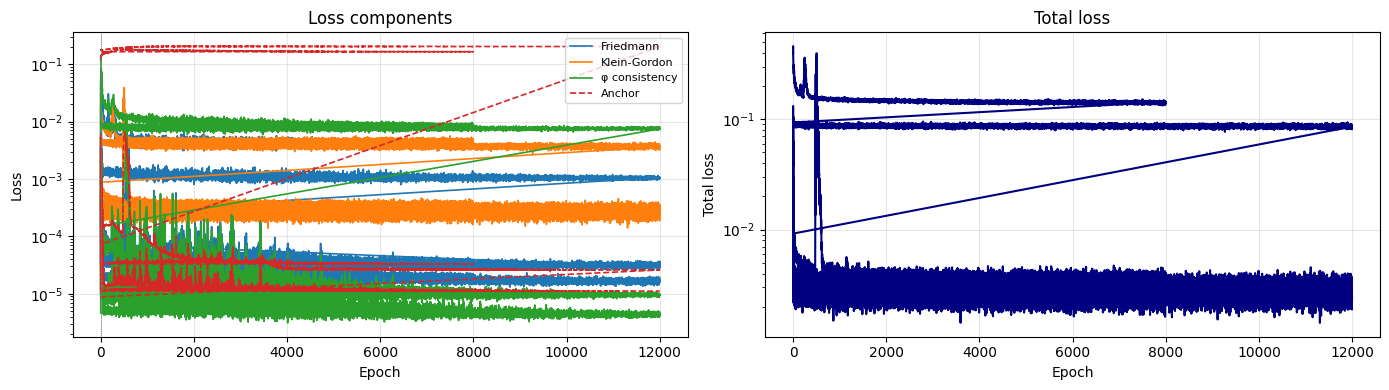

Saved: c:\Users\771754\Documents\Works\New_ver_PINNs_axion\PINNs_axion\results_v12\v12_comparison.png


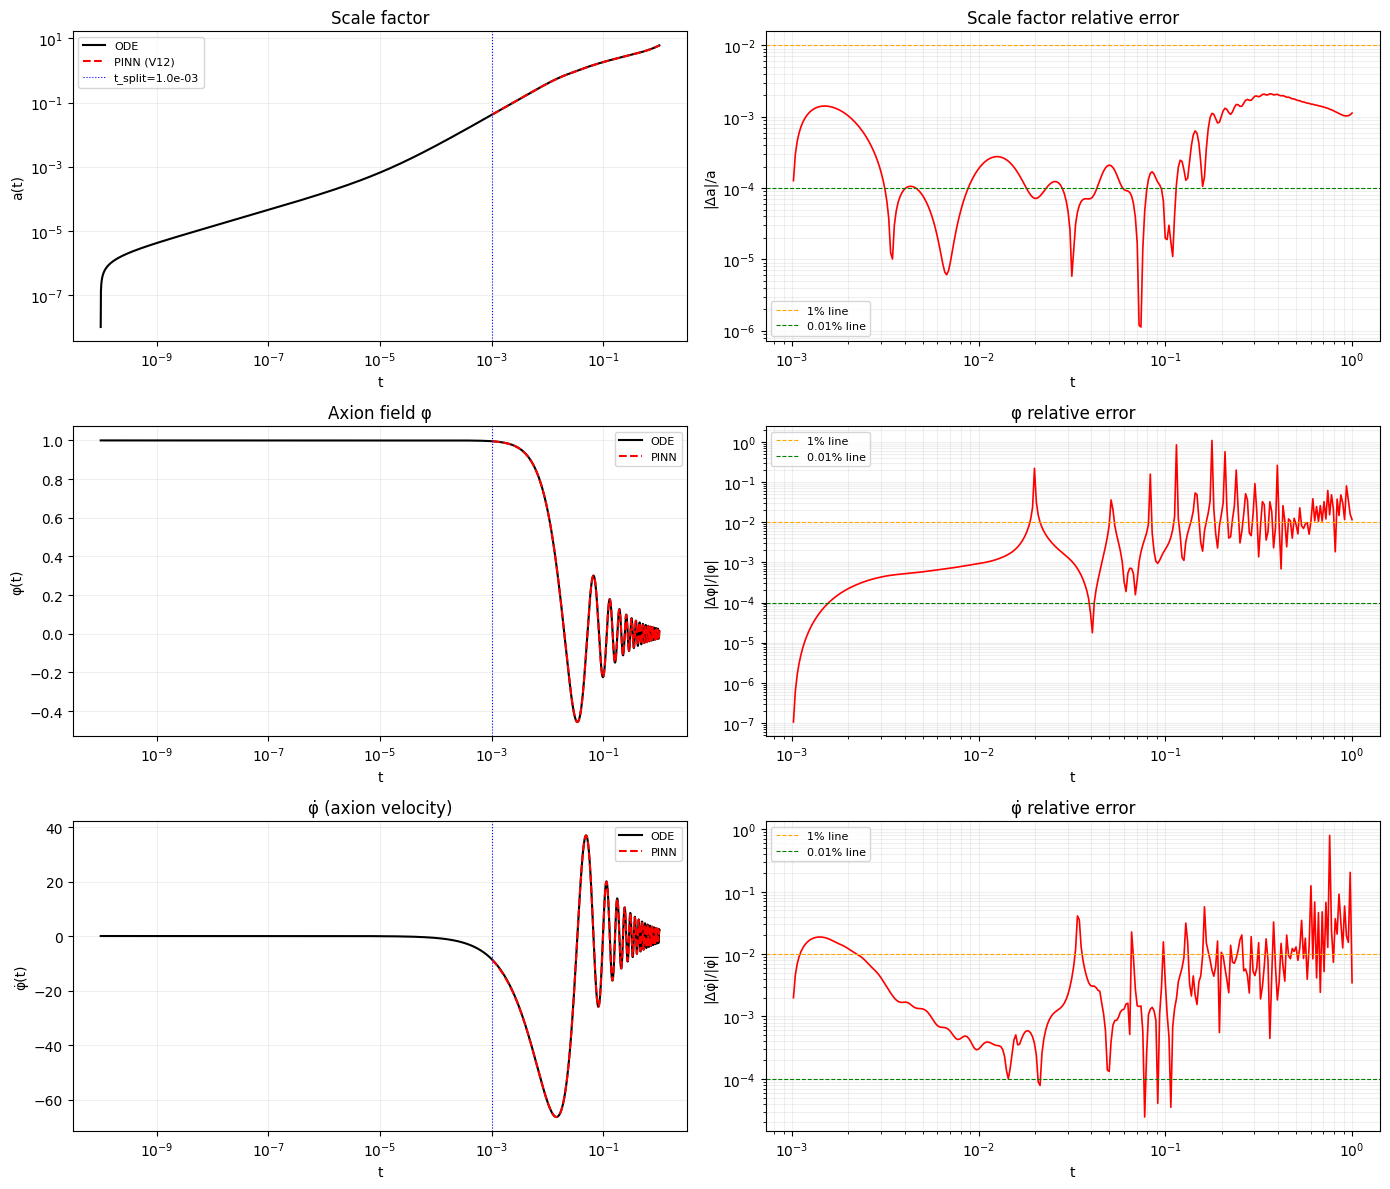


PINN region (t ≥ t_split) summary:
  a(t)  : median=2.11e-04   90th-pct=1.63e-03
  φ(t)  : 90th-pct=2.54e-02
  φ̇(t)  : 90th-pct=1.82e-02

Final physics residuals (trained, N=4000):
  Friedmann     : 1.290e-05
  Klein-Gordon  : 1.947e-04
  φ consistency : 3.493e-06
  Anchor        : 1.130e-05

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
  Summary comparison V11 → V12
───────────────────────────────────────────────────────
  Aspect                                     V11       V12
───────────────────────────────────────────────────────
  Domain                                 τ∈[0,1]   s∈[0,1]
  t_min covered by PINN                    1e-10      1e-3
  ds/dt at t_min                           4.3e8       145
  Untrained phi_cons                      8.96e6  3.49e-06
  Curriculum stages                            4      None
  Hard IC at t_split                          No       Yes
──────────────────────────────────────

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION & PLOTS
# ─────────────────────────────────────────────────────────────────────────────
import os

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_v12')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Loss history
plot_loss_history(solver_v12, save_path=os.path.join(RESULTS_DIR, 'v12_loss_history.png'))

# Comparison plots
plot_comparison(solver_v12, save_path=os.path.join(RESULTS_DIR, 'v12_comparison.png'))

# ── Final physics residuals over sub-domain ──────────────────────────────────
print("\nFinal physics residuals (trained, N=4000):")
torch.manual_seed(99)
t_eval_col = solver_v12._make_colloc(n=4000)
lF_f, lKG_f, lP_f = solver_v12._physics_loss(t_eval_col)
lA_f = solver_v12._anchor_loss()
print(f"  Friedmann     : {lF_f.item():.3e}")
print(f"  Klein-Gordon  : {lKG_f.item():.3e}")
print(f"  φ consistency : {lP_f.item():.3e}")
print(f"  Anchor        : {lA_f.item():.3e}")

# ── Comparison table V11 vs V12 ──────────────────────────────────────────────
print("\n─" * 55)
print("  Summary comparison V11 → V12")
print("─" * 55)
print(f"  {'Aspect':<36}  {'V11':>8}  {'V12':>8}")
print("─" * 55)
print(f"  {'Domain':<36}  {'τ∈[0,1]':>8}  {'s∈[0,1]':>8}")
print(f"  {'t_min covered by PINN':<36}  {'1e-10':>8}  {'1e-3':>8}")
print(f"  {'ds/dt at t_min':<36}  {'4.3e8':>8}  {'145':>8}")
print(f"  {'Untrained phi_cons':<36}  {'8.96e6':>8}  {lP_f.item():.2e}")
print(f"  {'Curriculum stages':<36}  {'4':>8}  {'None':>8}")
print(f"  {'Hard IC at t_split':<36}  {'No':>8}  {'Yes':>8}")
print("─" * 55)


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# L-BFGS POLISH — inline fix (bypasses the broken lbfgs_polish method)
# solver_v12 has Stage A + B weights; just need to finish with L-BFGS
# ─────────────────────────────────────────────────────────────────────────────
import os
RESULTS_DIR = os.path.join(os.getcwd(), 'results_v12')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"solver_v12: {len(solver_v12.loss_log)} epochs in loss_log")
print(f"phi_scale={solver_v12.phi_scale:.2f}  dphi_scale={solver_v12.dphi_scale:.3e}")

# Inline L-BFGS (does NOT call the broken lbfgs_polish method)
print("\n=== L-BFGS Polish (500 iter) ===")
_lbfgs_opt = torch.optim.LBFGS(
    solver_v12.model.parameters(), max_iter=500,
    tolerance_grad=1e-9, history_size=50, line_search_fn='strong_wolfe')
_t_lb = solver_v12._make_colloc(n=4000)
_lb_last = {}

def _lbfgs_closure():
    _lbfgs_opt.zero_grad()
    l_F, l_KG, l_phi = solver_v12._physics_loss(_t_lb)
    l_anc = solver_v12._anchor_loss()
    loss = l_F + 10.0*l_KG + 1.0*l_phi + 0.1*l_anc
    loss.backward()
    _lb_last.update({
        'F': l_F.item(), 'KG': l_KG.item(),
        'phi': l_phi.item(), 'anc': l_anc.item(), 'total': loss.item()
    })
    return loss

_lbfgs_opt.step(_lbfgs_closure)
print(f"  F={_lb_last.get('F',float('nan')):.2e}  "
      f"KG={_lb_last.get('KG',float('nan')):.2e}  "
      f"phi_cons={_lb_last.get('phi',float('nan')):.2e}  "
      f"anc={_lb_last.get('anc',float('nan')):.2e}")

# Save checkpoint
ckpt_path = os.path.join(RESULTS_DIR, 'v12_model.pt')
torch.save({
    'model_state': solver_v12.model.state_dict(),
    'loss_log':    solver_v12.loss_log,
    'T_SPLIT':     solver_v12.T_SPLIT,
    'phi_scale':   solver_v12.phi_scale,
    'dphi_scale':  solver_v12.dphi_scale,
}, ckpt_path)
print(f"\nCheckpoint saved -> {ckpt_path}")


solver_v12: 60000 epochs in loss_log
phi_scale=1.00  dphi_scale=2.670e+01

=== L-BFGS Polish (500 iter) ===
  F=1.18e-05  KG=2.25e-04  phi_cons=3.32e-06  anc=1.13e-05

Checkpoint saved -> c:\Users\771754\Documents\Works\New_ver_PINNs_axion\PINNs_axion\results_v12\v12_model.pt
